In [1]:
import numpy as np
import pandas as pd
import keras
import os

from PIL import Image

In [2]:
def get_count(dir_path):
    count = 0
    for path in os.listdir(dir_path):
        count += 1
    
    print('Original Images count:', count)
    print('Tampered Images count:', count)


print('Training data:')
get_count('../input/cg1050/TRAINING_CG-1050/TRAINING/ORIGINAL')

print('\nValidation data:')
get_count('../input/cg1050/VALIDATION_CG-1050/VALIDATION/ORIGINAL')

Training data:
Original Images count: 730
Tampered Images count: 730

Validation data:
Original Images count: 314
Tampered Images count: 314


In [3]:
original = Image.open('../input/cg1050/TRAINING_CG-1050/TRAINING/ORIGINAL/Im100_2_cm.jpg')

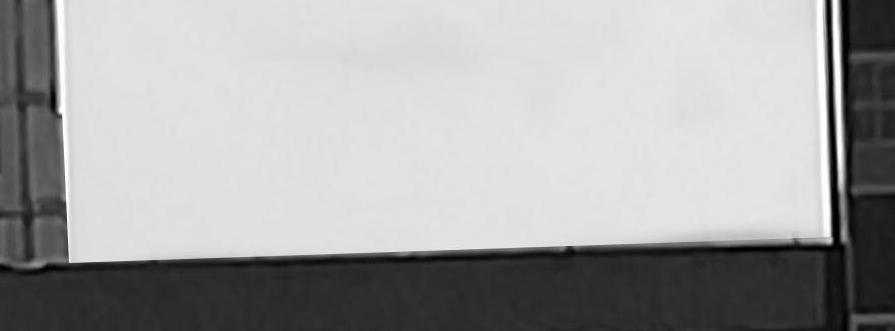

In [4]:
tampered = Image.open('../input/cg1050/TRAINING_CG-1050/TRAINING/TAMPERED/Im100_cm2.jpg')
tampered

In [5]:
from keras.preprocessing.image import ImageDataGenerator

img_shape = (224,224)  # Changed to 224x224 for better feature extraction

# Add strong data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Only rescale for validation
val_datagen = ImageDataGenerator(rescale=1./255)

training_data = train_datagen.flow_from_directory('../input/cg1050/TRAINING_CG-1050/TRAINING/ORIGINAL',
                                                  target_size=img_shape,
                                                  color_mode='rgb',
                                                  batch_size=32,  # Increased from 64
                                                  class_mode='binary',
                                                  seed=42,
                                                  interpolation='bilinear')

training_tampered = train_datagen.flow_from_directory('../input/cg1050/TRAINING_CG-1050/TRAINING/TAMPERED',
                                                       target_size=img_shape,
                                                       color_mode='rgb',
                                                       batch_size=32,
                                                       class_mode='binary',
                                                       seed=42,
                                                       interpolation='bilinear')

validation_data = val_datagen.flow_from_directory('../input/cg1050/VALIDATION_CG-1050/VALIDATION/ORIGINAL',
                                                  target_size=img_shape,
                                                  color_mode='rgb',
                                                  batch_size=32,
                                                  class_mode='binary',
                                                  seed=42,
                                                  interpolation='bilinear')

validation_tampered = val_datagen.flow_from_directory('../input/cg1050/VALIDATION_CG-1050/VALIDATION/TAMPERED',
                                                       target_size=img_shape,
                                                       color_mode='rgb',
                                                       batch_size=32,
                                                       class_mode='binary',
                                                       seed=42,
                                                       interpolation='bilinear')

Found 0 images belonging to 0 classes.
Found 0 images belonging to 0 classes.
Found 0 images belonging to 0 classes.
Found 0 images belonging to 0 classes.


In [6]:
import keras.models as M
import keras.layers as L
from keras.applications import VGG16
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

def make_model():
    # Use VGG16 with ImageNet weights for transfer learning
    base_model = VGG16(
        include_top=False,
        weights='imagenet',
        input_shape=(224, 224, 3),
        pooling='avg'
    )
    
    # Freeze base model layers initially
    base_model.trainable = False
    
    # Build the model
    model = M.Sequential([
        base_model,
        L.Dense(512, activation='relu'),
        L.BatchNormalization(),
        L.Dropout(0.5),
        L.Dense(256, activation='relu'),
        L.BatchNormalization(),
        L.Dropout(0.3),
        L.Dense(1, activation='sigmoid')
    ])
    
    # Compile with better optimizer settings
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

model = make_model()
model.summary()

ImportError: cannot import name 'VGG16' from 'keras.applications' (/opt/conda/lib/python3.7/site-packages/keras/applications/__init__.py)

In [ ]:
# Define callbacks for better training
checkpoint = ModelCheckpoint(
    '/kaggle/working/best_model.h5',
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    mode='max'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1,
    min_lr=0.00001
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    verbose=1,
    restore_best_weights=True
)

# Combine training and validation generators
import numpy as np

def combined_generator(gen1, gen2):
    while True:
        x1, y1 = next(gen1)
        x2, y2 = next(gen2)
        # Combine the batches
        x = np.concatenate([x1, x2])
        # Label original as 0, tampered as 1
        y = np.concatenate([np.zeros(len(y1)), np.ones(len(y2))])
        # Shuffle
        indices = np.arange(len(y))
        np.random.shuffle(indices)
        yield x[indices], y[indices]

# Create combined generators
train_gen = combined_generator(training_data, training_tampered)
val_gen = combined_generator(validation_data, validation_tampered)

# Calculate steps
steps_per_epoch = (730 + 730) // 32  # total training images / batch_size
validation_steps = (314 + 314) // 32  # total validation images / batch_size

print(f'Steps per epoch: {steps_per_epoch}')
print(f'Validation steps: {validation_steps}')

# Train the model
history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=validation_steps,
    epochs=30,  # Reduced epochs with early stopping
    callbacks=[checkpoint, reduce_lr, early_stop],
    verbose=1
)

In [ ]:
import matplotlib.pyplot as plt

loss=model.history.history['loss']
val_loss=model.history.history['val_loss']
acc=model.history.history['accuracy']
val_acc=model.history.history['val_accuracy']
epochs=[i for i in range(len(loss))]
plt.plot(epochs,loss)
plt.plot(epochs,val_loss)
plt.show();

In [ ]:
plt.plot(epochs,acc)
plt.plot(epochs,val_acc)
plt.show();

In [ ]:
import cv2

def predict_image(path):
    image=cv2.imread(path)
    image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
    plt.imshow(image)
    image=cv2.resize(image,(150,150))
    image=image.reshape(1,150,150,3)
    prediction=np.argmax(model.predict(image))
    labels=['Tampered','Original']
    return labels[prediction]


In [ ]:
predict_image('../input/cg1050/VALIDATION_CG-1050/VALIDATION/TAMPERED/Im100_cm1.jpg')

In [ ]:
import pandas as pd

# Get file paths from the validation generator
file_paths = validation_data.filepaths
preds = model.predict(validation_data)


# Predicted class indices
predicted_classes = np.argmax(preds, axis=1)

# Map class indices to class labels
labels = {v: k for k, v in validation_data.class_indices.items()}
predicted_labels = [labels[k] for k in predicted_classes]

# Create DataFrame
df = pd.DataFrame({
    'Filename': [os.path.basename(path) for path in file_paths],
    'Predicted Label': predicted_labels
})

# Save to CSV
csv_path = '/kaggle/working/predictions.csv'
df.to_csv(csv_path, index=False)

print(f"Predictions saved to {csv_path}")
df.head()
